In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Show all columns when we print the dataframe
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
# Load the file 
raw = pd.read_csv("../data/HHS_Unaccompanied_Alien_Children_Program.csv")

print("Shape (rows, columns):", raw.shape)
print("\nFirst 5 rows:")
raw.head()

Shape (rows, columns): (1170, 6)

First 5 rows:


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    str    
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    str    
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(2)
memory usage: 69.5 KB


### Rename columns to short names

In [5]:
# The original column names are very long — rename them so our code is readable
raw.columns = [
    "date",
    "cbp_apprehended",   # kids picked up at border daily
    "cbp_custody",       # total kids currently in CBP holding
    "cbp_transferred",   # kids moved from CBP to HHS that day
    "hhs_care",          # total kids currently in HHS shelters
    "hhs_discharged"     # kids released to sponsors that day
]

print("Renamed columns:", raw.columns.tolist())

Renamed columns: ['date', 'cbp_apprehended', 'cbp_custody', 'cbp_transferred', 'hhs_care', 'hhs_discharged']


### Previewing the blank rows

In [6]:
# How many rows have at least one missing value?
print("Total rows in raw file:", len(raw))
print("Rows with ALL values missing:", raw.isnull().all(axis=1).sum())
print("Rows with ANY value missing:", raw.isnull().any(axis=1).sum())

# Show missing count per column
print("\nMissing values per column:")
print(raw.isnull().sum())

# Preview the first few blank rows to confirm they're truly empty
first_blank_idx = raw[raw.isnull().all(axis=1)].index[0]
print(f"\nFirst blank row is at index {first_blank_idx} — previewing around it:")
raw.iloc[first_blank_idx - 2 : first_blank_idx + 3]

Total rows in raw file: 1170
Rows with ALL values missing: 450
Rows with ANY value missing: 450

Missing values per column:
date               450
cbp_apprehended    450
cbp_custody        450
cbp_transferred    450
hhs_care           450
hhs_discharged     450
dtype: int64

First blank row is at index 720 — previewing around it:


,date,cbp_apprehended,cbp_custody,cbp_transferred,hhs_care,hhs_discharged
718,"January 22, 2023",32.0,49.0,39.0,"7,122",227.0
719,"January 12, 2023",33.0,53.0,34.0,"6,566",436.0
720,NaN,NaN,NaN,NaN,NaN,NaN
721,NaN,NaN,NaN,NaN,NaN,NaN
722,NaN,NaN,NaN,NaN,NaN,NaN


### Drop the blank rows at the bottom

In [7]:
# The CSV has hundreds of empty rows — drop any row where ALL values are missing
df = raw.dropna(how="all").copy()

print(f"Rows before drop: {len(raw)}")
print(f"Rows after drop:  {len(df)}")

Rows before drop: 1170
Rows after drop:  720


### Parse the Date column

In [8]:
# Dates look like "December 21, 2025" — we tell pandas exactly that format
df["date"] = pd.to_datetime(df["date"], format="%B %d, %Y")

# Sort oldest → newest (data came in reverse order)
df = df.sort_values("date").reset_index(drop=True)

print("Date range:", df["date"].min(), "→", df["date"].max())
print("Total reporting days:", len(df))

Date range: 2023-01-12 00:00:00 → 2025-12-21 00:00:00
Total reporting days: 720


### Fix the HHS Care column (it has commas in numbers)

In [9]:
# check if it's NOT already numeric
if not pd.api.types.is_numeric_dtype(df["hhs_care"]):
    df["hhs_care"] = (
        df["hhs_care"]
        .astype(str)           # make sure it's a string first
        .str.replace(",", "")  # remove the comma e.g. "2,484" → "2484"
        .astype(int)           # convert to integer
    )
    print("Fixed hhs_care — commas removed, converted to int")
else:
    print("hhs_care already numeric — no fix needed")

print("\nColumn types:")
print(df.dtypes)

Fixed hhs_care — commas removed, converted to int

Column types:
date               datetime64[us]
cbp_apprehended           float64
cbp_custody               float64
cbp_transferred           float64
hhs_care                    int64
hhs_discharged            float64
dtype: object


### Check for missing values

In [10]:
missing = df.isnull().sum()

print("Missing values per column:")
print(missing)

# If any dates are missing, forward fill them (carry the last known value)
# This is standard practice for government daily reporting data
if missing.any():
    df = df.fillna(method="ffill")
    print("\nForward-filled missing values.")
else:
    print("\nNo missing values — data is clean!")

Missing values per column:
date               0
cbp_apprehended    0
cbp_custody        0
cbp_transferred    0
hhs_care           0
hhs_discharged     0
dtype: int64

No missing values — data is clean!


### Validate logical constraints

In [11]:
# These two rules MUST always be true in real life:
# 1. You can't transfer more kids than CBP is currently holding
# 2. You can't discharge more kids than HHS is currently caring for

transfer_violations = df[df["cbp_transferred"] > df["cbp_custody"]]
discharge_violations = df[df["hhs_discharged"] > df["hhs_care"]]

print(f"Transfer violations (transfers > CBP custody):   {len(transfer_violations)} rows")
print(f"Discharge violations (discharged > HHS care):   {len(discharge_violations)} rows")

# Show the problem rows if any exist — flag them for transparency
if len(transfer_violations) > 0:
    print("\nTransfer violations:")
    print(transfer_violations[["date", "cbp_transferred", "cbp_custody"]])

if len(discharge_violations) > 0:
    print("\nDischarge violations:")
    print(discharge_violations[["date", "hhs_discharged", "hhs_care"]])

Transfer violations (transfers > CBP custody):   86 rows
Discharge violations (discharged > HHS care):   0 rows

Transfer violations:
          date  cbp_transferred  cbp_custody
3   2023-01-24             47.0         42.0
4   2023-01-25             41.0         22.0
9   2023-02-02             23.0         13.0
22  2023-02-22            230.0        215.0
23  2023-02-23            178.0        162.0
..         ...              ...          ...
502 2025-01-30             47.0         42.0
503 2025-02-02             41.0         22.0
508 2025-02-09             23.0         13.0
512 2025-02-13             23.0         10.0
521 2025-02-27             17.0         15.0

[86 rows x 3 columns]


### Create derived columns

In [12]:
# ---- The 4 key metrics the project requires ----

# 1. Total system load: how many kids is the entire system responsible for right now?
df["total_system_load"] = df["cbp_custody"] + df["hhs_care"]

# 2. Net daily intake: are more kids coming in than leaving HHS?
#    Positive = system is filling up. Negative = system is relieving pressure.
df["net_daily_intake"] = df["cbp_transferred"] - df["hhs_discharged"]

# 3. Care load growth rate: percentage change in HHS load day over day
#    Tells us how fast the system is growing or shrinking
df["hhs_growth_rate_pct"] = df["hhs_care"].pct_change() * 100

# 4. Rolling averages: smooth out the day-to-day noise to see real trends
df["hhs_care_7day_avg"]  = df["hhs_care"].rolling(window=7).mean()
df["hhs_care_14day_avg"] = df["hhs_care"].rolling(window=14).mean()

# 5. Cumulative net intake: how much backlog has built up over time?
#    If this keeps going up, the system is under sustained pressure
df["cumulative_net_intake"] = df["net_daily_intake"].cumsum()

print("New columns added:")
new_cols = ["total_system_load", "net_daily_intake", "hhs_growth_rate_pct",
            "hhs_care_7day_avg", "hhs_care_14day_avg", "cumulative_net_intake"]
print(df[new_cols].head(10))

New columns added:
   total_system_load  net_daily_intake  hhs_growth_rate_pct  hhs_care_7day_avg  hhs_care_14day_avg  \
0             6619.0            -402.0                  NaN                NaN                 NaN   
1             7171.0            -188.0             8.467865                NaN                 NaN   
2             7330.0            -142.0             2.218478                NaN                 NaN   
3             7475.0            -128.0             2.101648                NaN                 NaN   
4             7560.0            -139.0             1.412619                NaN                 NaN   
5             7517.0            -292.0            -0.875564                NaN                 NaN   
6             7797.0            -167.0             3.626874        7307.714286                 NaN   
7             7839.0            -122.0             0.774893        7484.428571                 NaN   
8             7935.0            -204.0             1.281558    

### Summary statistics

In [17]:
# Get a high-level feel for the numbers before we dive into EDA
print("DATASET SUMMARY:\n")
print(f"Date range:            {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Total reporting days:  {len(df)}")
print(f"\nPeak HHS care load:    {df['hhs_care'].max():,} children  on {df.loc[df['hhs_care'].idxmax(), 'date'].date()}")
print(f"Lowest HHS care load:  {df['hhs_care'].min():,} children  on {df.loc[df['hhs_care'].idxmin(), 'date'].date()}")
print(f"\nAvg daily intake into HHS:   {df['cbp_transferred'].mean():.0f} children/day")
print(f"Avg daily discharge from HHS: {df['hhs_discharged'].mean():.0f} children/day")
print(f"\nPeak total system load: {df['total_system_load'].max():,}")
print(f"Avg net daily intake:   {df['net_daily_intake'].mean():.1f} (positive = system filling up)")

DATASET SUMMARY:

Date range:            2023-01-12 to 2025-12-21
Total reporting days:  720

Peak HHS care load:    11,516 children  on 2023-12-20
Lowest HHS care load:  1,972 children  on 2025-08-21

Avg daily intake into HHS:   129 children/day
Avg daily discharge from HHS: 173 children/day

Peak total system load: 11,762.0
Avg net daily intake:   -44.7 (positive = system filling up)


In [14]:
import json

# Build the summary as a dictionary
summary = {
    "date_range": {
        "start": str(df["date"].min().date()),
        "end":   str(df["date"].max().date())
    },
    "total_reporting_days": len(df),
    "hhs_care": {
        "peak_value": int(df["hhs_care"].max()),
        "peak_date":  str(df.loc[df["hhs_care"].idxmax(), "date"].date()),
        "lowest_value": int(df["hhs_care"].min()),
        "lowest_date":  str(df.loc[df["hhs_care"].idxmin(), "date"].date())
    },
    "averages": {
        "daily_intake_into_hhs":    round(df["cbp_transferred"].mean(), 1),
        "daily_discharge_from_hhs": round(df["hhs_discharged"].mean(), 1),
        "net_daily_intake":         round(df["net_daily_intake"].mean(), 1)
    },
    "system_load": {
        "peak_total": int(df["total_system_load"].max())
    }
}

# Save to outputs/reports/
output_path = "../outputs/reports/dataset_summary.json"
with open(output_path, "w") as f:
    json.dump(summary, f, indent=4)

print(f"\nSaved to {output_path}")


Saved to ../outputs/reports/dataset_summary.json


### Quick sanity-check plot

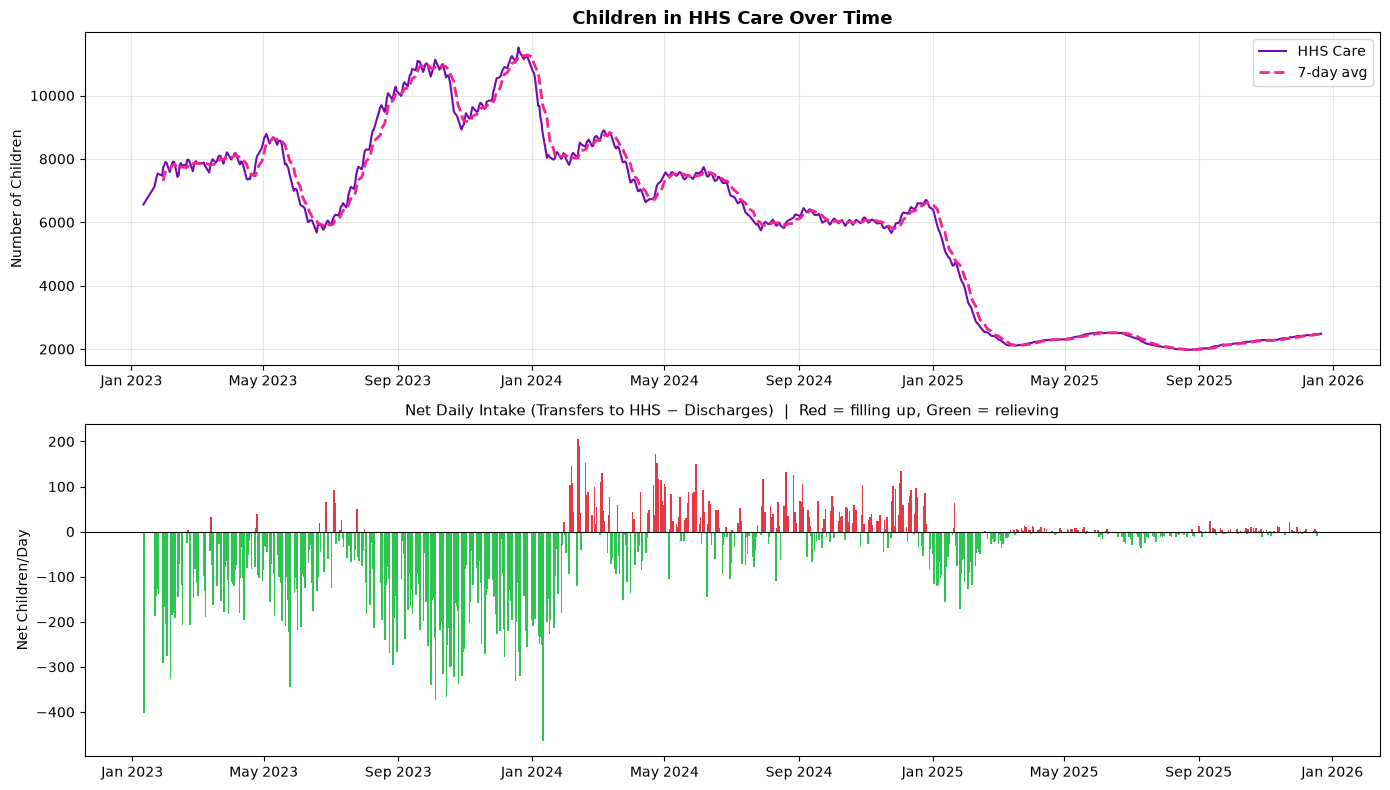

Plot saved to data/phase1_sanity_check.png


In [15]:
# A fast visual to confirm data looks correct before we move to full EDA

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top chart: HHS care over time
axes[0].plot(df["date"], df["hhs_care"], color="#7209b7", linewidth=1.5, label="HHS Care")
axes[0].plot(df["date"], df["hhs_care_7day_avg"], color="#f72585", linewidth=2,
             linestyle="--", label="7-day avg")
axes[0].set_title("Children in HHS Care Over Time", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Children")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Bottom chart: net daily intake (inflow minus outflow)
colors = ["#2dc653" if x <= 0 else "#e63946" for x in df["net_daily_intake"]]
axes[1].bar(df["date"], df["net_daily_intake"], color=colors, width=1.5)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Net Daily Intake (Transfers to HHS − Discharges)  |  Red = filling up, Green = relieving",
                  fontsize=11)
axes[1].set_ylabel("Net Children/Day")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.savefig("../outputs/charts/phase1_sanity_check.png", dpi=150)
plt.show()
print("Plot saved to data/phase1_sanity_check.png")

### Save the cleaned dataset

In [16]:
# Save the clean, enriched dataframe so Phase 2 (EDA) can just load this
# No need to re-clean every time
df.to_csv("../data/cleaned_uac_data.csv", index=False)

print(f"Saved cleaned data: {len(df)} rows, {len(df.columns)} columns")
print("Columns:", df.columns.tolist())

Saved cleaned data: 720 rows, 12 columns
Columns: ['date', 'cbp_apprehended', 'cbp_custody', 'cbp_transferred', 'hhs_care', 'hhs_discharged', 'total_system_load', 'net_daily_intake', 'hhs_growth_rate_pct', 'hhs_care_7day_avg', 'hhs_care_14day_avg', 'cumulative_net_intake']
